# Tutorial 8 – Equity Screening & Stock Selection Case
## FINM3422 – Professional Equity Research Workflow

**Estimated time:** ~2 hours (group-based)

---

### Scenario

You are part of a junior **equity research team** at an asset management firm.

Management has asked your team to:

> **Screen a universe of NASDAQ-listed technology companies and recommend ONE stock**
> for deeper fundamental analysis later in the course.

This notebook is intentionally structured like a **professional research notebook**,
following the modelling discipline discussed in **Lecture 6**.

You will work **collaboratively** using GitHub feature branches and pull requests.

## 1. Environment & Imports (≈5 minutes)

Professional modelling always begins by making the computing environment explicit.

Why this matters:
- Reproducibility across machines
- Clear collaboration in teams
- Fewer hidden bugs caused by implicit state

In this tutorial, we use **yfinance**, a free and stable Python library that provides
programmatic access to Yahoo Finance data.

No API key is required, which removes setup friction during tutorials.

In [43]:
# If needed (run once): pip install yfinance in console or use %pip install yfinance in your notebook

%pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")


[notice] A new release of pip is available: 25.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## What is the yfinance API?

`yfinance` is a Python wrapper around Yahoo Finance endpoints.
It allows analysts to retrieve:

- historical price data (daily, weekly, monthly)
- company metadata
- financial statements (income statement, balance sheet, cash flow)

It is:
- ✅ free
- ✅ fast to learn
- ✅ widely used for research prototyping and teaching

⚠️ Important:
`yfinance` is **not an institutional-grade data source** (e.g. Bloomberg or Refinitiv),
but it is perfectly suitable for **learning professional modelling workflows**.

## 2. Define the Investment Universe (≈5 minutes)

Equity research always begins with a clearly defined **investment universe**.

We restrict attention to a curated list of **large‑cap NASDAQ technology companies**.

Using a fixed universe ensures:
- Comparability across tutorial teams
- Stable API behaviour in class
- Focus on modelling rather than data hunting

In [44]:
tickers = [
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "NVDA",  # Nvidia
    "ADBE",  # Adobe
    "META",  # Meta Platforms
    "CRM",   # Salesforce
    "ORCL",  # Oracle
    "NOW",   # ServiceNow
    "INTU",  # Intuit
    "AMD"    # Advanced Micro Devices
]

## 3. Price Data Ingestion – API → DataFrame (≈15 minutes)

In professional workflows, analysts **do not manually download CSV files**.
Instead, data is pulled programmatically via APIs.

The main function used by yfinance is:

    yf.download()

### Key parameters you must understand

- `tickers`
  A single ticker (string) or multiple tickers (list)

- `interval`
  Controls **frequency** of observations  
  Examples:
  - `"1d"`  → daily data
  - `"1wk"` → weekly data
  - `"1mo"` → monthly data

- `period`
  Controls **how much history** is returned  
  Examples:
  - `"1y"`   → last year
  - `"5y"`   → last 5 years
  - `"max"`  → full available history

⚠️ **Critical rule**
> Never rely on API defaults. Always specify `period` explicitly.

## Why We Use Monthly Data in This Tutorial

In FINM3422:
- portfolio returns are monthly
- performance metrics are monthly
- Assignment 2 uses monthly frequency

Therefore, we deliberately request:
- `interval = "1mo"` → monthly observations
- `period = "max"`   → long historical window

This ensures:
- frequency is correct before computing returns
- enough observations exist for rolling metrics
- alignment with Lecture 6 modelling discipline

In [45]:
# TODO:
# Use yf.download to retrieve monthly adjusted prices
# - interval="1mo"
# - period="max"
# - auto_adjust=True
# Then:
# - keep adjusted close prices
# - ensure DatetimeIndex
# - sort index

In [46]:


yf.download(['AAPL', 'MSFT', 'NVDA', 'ADBE', 'META', 'CRM', 'ORCL', 'NOW', 'INTU', 'AMD'], interval="1mo", period="max", auto_adjust=True)



[*********************100%***********************]  10 of 10 completed


Price            Close                                                  \
Ticker            AAPL        ADBE         AMD         CRM        INTU   
Date                                                                     
1985-01-01    0.099152         NaN   17.562500         NaN         NaN   
1985-02-01    0.084621         NaN   16.625000         NaN         NaN   
1985-03-01    0.075646         NaN   16.687500         NaN         NaN   
1985-04-01    0.072655         NaN   13.937500         NaN         NaN   
1985-05-01    0.059406         NaN   13.250000         NaN         NaN   
...                ...         ...         ...         ...         ...   
2025-12-01  271.605835  349.989990  214.160004  263.823273  659.165161   
2026-01-01  259.237427  293.250000  236.729996  211.760376  496.468567   
2026-02-01  263.933014  262.410004  200.210007  194.304047  407.769867   
2026-03-01  253.789993  243.080002  203.429993  186.204300  431.047943   
2026-04-01  273.170013  255.940002  303.459991  189.800003  408.679993   

Price                                                                   ...  \
Ticker            META        MSFT         NOW        NVDA        ORCL  ...   
Date                                                                    ...   
1985-01-01         NaN         NaN         NaN         NaN         NaN  ...   
1985-02-01         NaN         NaN         NaN         NaN         NaN  ...   
1985-03-01         NaN         NaN         NaN         NaN         NaN  ...   
1985-04-01         NaN         NaN         NaN         NaN         NaN  ...   
1985-05-01         NaN         NaN         NaN         NaN         NaN  ...   
...                ...         ...         ...         ...         ...  ...   
2025-12-01  658.987854  482.518677  153.190002  186.479538  193.719543  ...   
2026-01-01  715.887085  429.310120  117.010002  191.119659  163.574799  ...   
2026-02-01  647.625488  391.845612  108.010002  177.180420  144.893936  ...   
2026-03-01  571.640564  370.170013  104.550003  174.390549  146.597992  ...   
2026-04-01  674.719971  432.920013  103.070000  202.500000  187.500000  ...   

Price           Volume                                                    \
Ticker            AAPL         ADBE        AMD          CRM         INTU   
Date                                                                       
1985-01-01  6366416000          NaN   25653400          NaN          NaN   
1985-02-01  4733388800          NaN   14944400          NaN          NaN   
1985-03-01  4615587200          NaN   17758000          NaN          NaN   
1985-04-01  2868028800          NaN   14843600          NaN          NaN   
1985-05-01  4639129600          NaN   17080800          NaN          NaN   
...                ...          ...        ...          ...          ...   
2025-12-01   924528800   94756100.0  599995500  180318300.0   37699300.0   
2026-01-01  1040017300  100462600.0  759653200  192478000.0   58464000.0   
2026-02-01   988921000  119274500.0  821118200  300183700.0  102929300.0   
2026-03-01   900035700  141420400.0  750845500  289214200.0   80406000.0   
2026-04-01   632024684   76794108.0  531735290  208576150.0   54056124.0   

Price                                                                         
Ticker             META         MSFT          NOW          NVDA         ORCL  
Date                                                                          
1985-01-01          NaN          NaN          NaN           NaN          NaN  
1985-02-01          NaN          NaN          NaN           NaN          NaN  
1985-03-01          NaN          NaN          NaN           NaN          NaN  
1985-04-01          NaN          NaN          NaN           NaN          NaN  
1985-05-01          NaN          NaN          NaN           NaN          NaN  
...                 ...          ...          ...           ...          ...  
2025-12-01  335266200.0  496558500.0  209296000.0  3.629694e+09  690949100.0  
2

In [47]:
data = yf.download(tickers, interval="1mo", period="max", auto_adjust=True)
prices = data["Close"]
prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index()

[*********************100%***********************]  10 of 10 completed


## 4. Data Inspection & Sanity Checks (≈10 minutes)

Before computing metrics, analysts **inspect the raw data**.

You should check:
- `.info()`
- missing values (`.isna().sum()`)
- index type (`type(df.index)`)
- chronological ordering

### Important modelling principle (Lecture 6)

> NA does **not** mean bad data.
> It often means the company did not exist yet (IPO timing).

Different firms have different listing dates.
This is **economically correct**, not an error.

In [48]:
# TODO:
# Inspect the price DataFrame:
# - info()
# - missing values
# - index properties


In [49]:
prices.info()
prices.isna().sum()
type(prices.index)




<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 496 entries, 1985-01-01 to 2026-04-01
Freq: MS
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    496 non-null    float64
 1   ADBE    477 non-null    float64
 2   AMD     496 non-null    float64
 3   CRM     263 non-null    float64
 4   INTU    398 non-null    float64
 5   META    168 non-null    float64
 6   MSFT    482 non-null    float64
 7   NOW     167 non-null    float64
 8   NVDA    328 non-null    float64
 9   ORCL    482 non-null    float64
dtypes: float64(10)
memory usage: 42.6 KB


pandas.core.indexes.datetimes.DatetimeIndex

## 5. Returns & Performance Metrics (≈15 minutes)

Equity screeners often include **recent market performance**
(e.g. momentum or confirmation).

Tasks:
- Compute monthly returns
- Compute trailing 12‑month total return

⚠️ Always fix frequency *before* computing returns.

In [50]:
# TODO:
# 1. Compute monthly returns using pct_change()
# 2. Compute trailing 12‑month total return

In [51]:
returns = prices.pct_change()
returns = returns.dropna()
returns

Ticker,AAPL,ADBE,AMD,CRM,INTU,META,MSFT,NOW,NVDA,ORCL
Date,,,,,,,,,,
2012-07-01,0.045822,-0.046030,-0.291449,-0.100535,-0.022409,-0.301929,-0.036613,0.097561,-0.020261,0.016835
2012-08-01,0.089200,0.012630,-0.083744,0.167417,0.011494,-0.168125,0.045809,0.151852,0.036189,0.050182
2012-09-01,0.007102,0.037416,-0.094086,0.051729,0.005808,0.199336,-0.027996,0.243730,-0.049181,-0.006003
2012-10-01,-0.107600,0.049014,-0.391691,-0.043945,0.009341,-0.025393,-0.040995,-0.207601,-0.101949,-0.012079
2012-11-01,-0.016866,0.017044,0.073171,0.080079,0.010891,0.326386,-0.067274,0.064600,-0.000834,0.037423
...,...,...,...,...,...,...,...,...,...,...
2025-12-01,-0.024122,0.093275,-0.015492,0.149085,0.044695,0.018736,-0.015213,-0.057188,0.053672,-0.034860
2026-01-01,-0.045538,-0.162119,0.105388,-0.197340,-0.246822,0.086343,-0.110273,-0.236177,0.024883,-0.155610
2026-02-01,0.018113,-0.105166,-0.154269,-0.082434,-0.178659,-0.095352,-0.087267,-0.076917,-0.072935,-0.114204


In [52]:
trailing_12m = (1 + returns).rolling(12).apply(lambda x: x.prod() - 1)
trailing_12m = trailing_12m.dropna()
trailing_12m

Ticker,AAPL,ADBE,AMD,CRM,INTU,META,MSFT,NOW,NVDA,ORCL
Date,,,,,,,,,,
2013-06-01,-0.306427,0.407476,-0.287958,0.104585,0.039505,-0.200000,0.163537,0.641870,0.033972,0.043990
2013-07-01,-0.243158,0.531088,-0.071429,0.407205,0.113504,0.695072,0.113346,0.614074,0.085421,0.081534
2013-08-01,-0.251873,0.463064,-0.120968,0.353630,0.097116,1.286268,0.116737,0.507396,0.070001,0.018131
2013-09-01,-0.268312,0.601110,0.130564,0.359879,0.138512,1.319021,0.152842,0.343071,0.193130,0.066395
2013-10-01,-0.101066,0.593300,0.629268,0.462118,0.214730,1.378494,0.279061,0.781729,0.296985,0.090173
...,...,...,...,...,...,...,...,...,...,...
2025-12-01,0.090526,-0.212940,0.772994,-0.202843,0.060934,0.130921,0.155842,-0.277487,0.389184,0.181281
2026-01-01,0.104464,-0.329638,1.041656,-0.374668,-0.165073,0.042920,0.044341,-0.425509,0.592257,-0.022598
2026-02-01,0.097316,-0.401655,1.004907,-0.341744,-0.329132,-0.026902,-0.003408,-0.419151,0.418816,-0.115540


## 6. Visual Diagnostics – Wealth Index (≈15 minutes)

Before trusting any metric, professional analysts **plot a wealth index**.

A wealth index answers:
> What happens to $1 invested over time?

This diagnostic reveals:
- missing months
- compounding errors
- extreme outliers dominating results

In [53]:
# TODO:
# Construct and plot wealth indices
# Plot at least 3 stocks
# Add a brief interpretation

<Axes: xlabel='Date'>

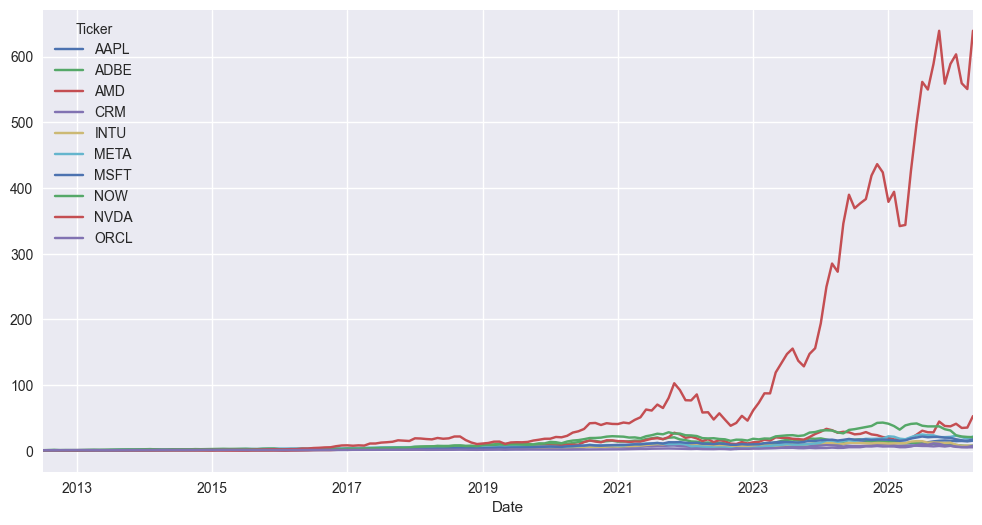

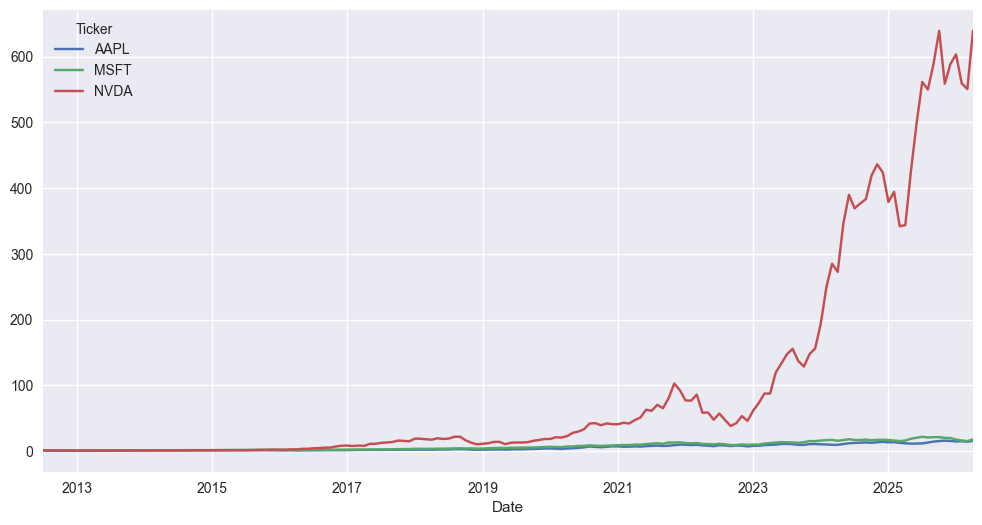

In [54]:
wealth_index = (1 + returns).cumprod()
wealth_index.plot(figsize=(12, 6))
wealth_index[["AAPL", "MSFT", "NVDA"]].plot(figsize=(12, 6))

NVDA has the highest growth, but also highest volatility. AAPL is steady and consistent. MSFT is strong in recent years. Different start dates. 

## 7. Fundamental Indicators – Growth & Quality (≈20 minutes)

Market prices alone are not sufficient for equity analysis.

We complement price performance with **fundamentals**.

Two indicators:
- **Revenue growth** (latest year vs previous year)
- **Operating margin** (operating income / revenue)

Financial statements are accessed using:

    yf.Ticker("AAPL").financials

In [55]:
# TODO:
# For each ticker:
# - retrieve financial statements using yf.Ticker
# - compute revenue growth
# - compute operating margin
# Store results in a DataFrame

In [56]:
fin = yf.Ticker("AAPL").financials

fin 

,2025-09-30,2024-09-30,2023-09-30,2022-09-30,2021-09-30
Tax Effect Of Unusual Items,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
Tax Rate For Calcs,1.560000e-01,2.410000e-01,1.470000e-01,1.620000e-01,NaN
Normalized EBITDA,1.447480e+11,1.346610e+11,1.258200e+11,1.305410e+11,NaN
Net Income From Continuing Operation Net Minority Interest,1.120100e+11,9.373600e+10,9.699500e+10,9.980300e+10,NaN
Reconciled Depreciation,1.169800e+10,1.144500e+10,1.151900e+10,1.110400e+10,NaN
Reconciled Cost Of Revenue,2.209600e+11,2.103520e+11,2.141370e+11,2.235460e+11,NaN
EBITDA,1.447480e+11,1.346610e+11,1.258200e+11,1.305410e+11,NaN
EBIT,1.330500e+11,1.232160e+11,1.143010e+11,1.194370e+11,NaN
Net Interest Income,NaN,NaN,-1.830000e+08,-1.060000e+08,1.980000e+08
Interest Expense,NaN,NaN,3.933000e+09,2.931000e+09,2.645000e+09


In [57]:
revenue = fin.loc["Total Revenue"]
revenue

op_income = fin.loc["Operating Income"]

In [58]:
rev_latest = revenue.iloc[0]
rev_prev = revenue.iloc[1]

op_latest = op_income.iloc[0]
op_prev = op_income.iloc[1]

rev_growth = (rev_latest - rev_prev) / rev_prev
op_margin = op_latest / rev_latest

print("Revenue Growth:", rev_growth)
print("Operating Margin:", op_margin)

Revenue Growth: 0.0642551178283274
Operating Margin: 0.31970799762591884


In [59]:
import pandas as pd

tickers = ['AAPL','MSFT','NVDA','ADBE','META','CRM','ORCL','NOW','INTU','AMD']

results = []

for ticker in tickers:
    t = yf.Ticker(ticker)
    fin = t.financials
    
    if fin is None or fin.empty:
        continue
    
    try:
        revenue = fin.loc["Total Revenue"]
        op_income = fin.loc["Operating Income"]
        
        rev_latest = revenue.iloc[0]
        rev_prev = revenue.iloc[1]
        op_latest = op_income.iloc[0]
        
        rev_growth = (rev_latest - rev_prev) / rev_prev
        op_margin = op_latest / rev_latest
        
        results.append({
            "Ticker": ticker,
            "Revenue Growth": rev_growth,
            "Operating Margin": op_margin
        })
        
    except:
        continue

In [60]:
fundamentals = pd.DataFrame(results).set_index("Ticker")
fundamentals

,Revenue Growth,Operating Margin
Ticker,,
AAPL,0.064255,0.319708
MSFT,0.149322,0.456220
NVDA,0.654735,0.603817
ADBE,0.105278,0.366275
META,0.221670,0.414379
CRM,0.095791,0.214738
ORCL,0.083798,0.314500
NOW,0.208849,0.137370
INTU,0.156340,0.262227


## 8. Screening Table Construction (≈15 minutes)

Professional screeners combine **all signals into one master table**.

Structure:
- each row → one stock
- each column → one screening signal

This table forms the basis for ranking and decision‑making.

In [ ]:
# TODO:
# Combine:
# - 12‑month return
# - revenue growth
# - operating margin
# into a single screening table

In [61]:
latest_12m_return = trailing_12m.iloc[-1].to_frame(name="12M Return")

screen = latest_12m_return.join(fundamentals, how="inner")

screen

,12M Return,Revenue Growth,Operating Margin
Ticker,,,
AAPL,0.291109,0.064255,0.319708
ADBE,-0.317457,0.105278,0.366275
AMD,2.117206,0.343378,0.106643
CRM,-0.287273,0.095791,0.214738
INTU,-0.342240,0.156340,0.262227
META,0.232832,0.221670,0.414379
MSFT,0.103664,0.149322,0.456220
NOW,-0.460372,0.208849,0.137370
NVDA,0.859601,0.654735,0.603817


## 9. Ranking & Shortlisting Logic (≈15 minutes)

Equity screening is about **narrowing the universe**, not precision.

Rank stocks using:
- revenue growth
- operating margin
- 12‑month performance

Combine ranks into a **composite score**.

There is no single correct answer —
only defensible logic that can be explained.

In [ ]:
# TODO:
# Rank each metric
# Compute composite score
# Sort stocks from most to least attractive

In [62]:
ranks = screen.rank(ascending=False)
ranks

,12M Return,Revenue Growth,Operating Margin
Ticker,,,
AAPL,4.0,10.0,5.0
ADBE,8.0,7.0,4.0
AMD,1.0,2.0,10.0
CRM,7.0,8.0,8.0
INTU,9.0,5.0,7.0
META,5.0,3.0,3.0
MSFT,6.0,6.0,2.0
NOW,10.0,4.0,9.0
NVDA,2.0,1.0,1.0


In [64]:
ranks["Composite Score"] = ranks.sum(axis=1)
ranking = ranks.sort_values("Composite Score")
ranking

,12M Return,Revenue Growth,Operating Margin,Composite Score
Ticker,,,,
NVDA,2.0,1.0,1.0,4.0
META,5.0,3.0,3.0,11.0
AMD,1.0,2.0,10.0,13.0
MSFT,6.0,6.0,2.0,14.0
ORCL,3.0,9.0,6.0,18.0
AAPL,4.0,10.0,5.0,19.0
ADBE,8.0,7.0,4.0,19.0
INTU,9.0,5.0,7.0,21.0
CRM,7.0,8.0,8.0,23.0


NVDA appears to before the best. 

## 10. Stock Selection – Analyst Decision (≈10 minutes)

Your team must now make a **judgement call**.

Select **ONE stock** to recommend for deeper analysis.

Write as if presenting to an **investment committee**.

In [ ]:
### Selected Stock

### Analyst Rationale
- Growth outlook:
- Profitability / quality:
- Market performance:
- Key risks:

NVDA is clearly the strongest.

Growth outlook:

65% revenue growth. Significantly outperforms peers. 

Profitability:

Highest operating margin of 60%. 

Market performance:

12 month returns are strong at 85%, the second highest among its peers. Operational efficiency aligns with investor confidence. 

Key risks:

AI bubble bursting potentially. Cyclical factors. Slowdown in AI investment.

## 11. GitHub Collaboration Reflection (≈10 minutes)

Equity research is a **team activity**.

Document:
- Who worked on which sections
- How feature branches and pull requests were used
- Any challenges encountered

- Member A:
- Member B:
- Member C: